<a href="https://colab.research.google.com/github/Henriqueqb/Henrique/blob/main/An%C3%A1lise_Descritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
# <font color=green size=10>CURSO DE ESTATÍSTICA - PARTE 1</font>
***

## Trabalho de Análise Descritiva de um Conjunto de Dados

Utilizando os conhecimentos adquiridos em nosso treinamento realize uma análise descritiva básica de um conjunto de dados retirados da Pesquisa Nacional por Amostra de Domicílios - 2015 do IBGE.

Vamos construir histogramas, calcular e avaliar medidas de tendência central, medidas separatrizes e de dispersão dos dados.

Siga o roteiro proposto e vá completando as células vazias. Procure pensar em mais informações interessantes que podem ser exploradas em nosso dataset.

# <font color=green>DATASET DO PROJETO</font>
***

### Pesquisa Nacional por Amostra de Domicílios - 2015

A <b>Pesquisa Nacional por Amostra de Domicílios - PNAD</b> investiga anualmente, de forma permanente, características gerais da população, de educação, trabalho, rendimento e habitação e outras, com periodicidade variável, de acordo com as necessidades de informação para o país, como as características sobre migração, fecundidade, nupcialidade, saúde, segurança alimentar, entre outros temas. O levantamento dessas estatísticas constitui, ao longo dos 49 anos de realização da pesquisa, um importante instrumento para formulação, validação e avaliação de políticas orientadas para o desenvolvimento socioeconômico e a melhoria das condições de vida no Brasil.

### Fonte dos Dados

https://ww2.ibge.gov.br/home/estatistica/populacao/trabalhoerendimento/pnad2015/microdados.shtm

### Variáveis utilizadas

> ### Renda
> ***

Rendimento mensal do trabalho principal para pessoas de 10 anos ou mais de idade.

> ### Idade
> ***

Idade do morador na data de referência em anos.

> ### Altura (elaboração própria)
> ***

Altura do morador em metros.

> ### UF
> ***

|Código|Descrição|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo
> ***

|Código|Descrição|
|---|---|
|0|Masculino|
|1|Feminino|

> ### Anos de Estudo
> ***

|Código|Descrição|
|---|---|
|1|Sem instrução e menos de 1 ano|
|2|1 ano|
|3|2 anos|
|4|3 anos|
|5|4 anos|
|6|5 anos|
|7|6 anos|
|8|7 anos|
|9|8 anos|
|10|9 anos|
|11|10 anos|
|12|11 anos|
|13|12 anos|
|14|13 anos|
|15|14 anos|
|16|15 anos ou mais|
|17|Não determinados|
||Não aplicável|

> ### Cor
> ***

|Código|Descrição|
|---|---|
|0|Indígena|
|2|Branca|
|4|Preta|
|6|Amarela|
|8|Parda|
|9|Sem declaração|

#### <font color='red'>Observação</font>
***
> Os seguintes tratamentos foram realizados nos dados originais:
> 1. Foram eliminados os registros onde a <b>Renda</b> era inválida (999 999 999 999);
> 2. Foram eliminados os registros onde a <b>Renda</b> era missing;
> 3. Foram considerados somente os registros das <b>Pessoas de Referência</b> de cada domicílio (responsável pelo domicílio).

***
***

### Utilize a célula abaixo para importar as biblioteca que precisar para executar as tarefas
#### <font color='red'>Sugestões: pandas, numpy, seaborn</font>

In [ ]:
import pandas
import numpy
import seaborn
import scipy

### Importe o dataset e armazene o conteúdo em uma DataFrame

In [ ]:
dados = pandas.read_csv('dados.csv')

### Visualize o conteúdo do DataFrame

In [ ]:
dados

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631
...,...,...,...,...,...,...,...
76835,53,1,46,2,11,812,1.687030
76836,53,0,30,4,7,1500,1.792934
76837,53,0,32,8,12,1300,1.830587
76838,53,0,57,8,4,1500,1.726344


### Para avaliarmos o comportamento da variável RENDA vamos construir uma tabela de frequências considerando as seguintes classes em salários mínimos (SM)
#### <font color='blue'>Descreva os pontos mais relevantes que você observa na tabela e no gráfico.</font>

Classes de renda:

<b>A</b> ► Acima de 25 SM

<b>B</b> ► De 15 a 25 SM

<b>C</b> ► De 5 a 15 SM

<b>D</b> ► De 2 a 5 SM

<b>E</b> ► Até 2 SM

Para construir as classes de renda considere que o salário mínimo na época da pesquisa era de <b>R$ 788,00</b>.

#### Siga os passos abaixo:

### 1º Definir os intevalos das classes em reais (R$)

In [ ]:
classes = [0, 1576, 3940, 11820, 19700, 200000]

### 2º Definir os labels das classes

In [ ]:
labels = ['E', 'D', 'C', 'B', 'A']

### 3º Construir a coluna de frequências

In [ ]:
frequencia_abs = pandas.Series(
    pandas.cut(x = dados.Renda,
               bins = classes,
               labels = labels,
               include_lowest = True)).value_counts()
frequencia_abs

,count
Renda,
E,49755
D,18602
C,7241
B,822
A,420


### 4º Construir a coluna de percentuais

In [ ]:
frequencia_perc = pandas.Series(
    pandas.cut(x = dados.Renda,
               bins = classes,
               labels = labels,
               include_lowest = True)).value_counts(normalize = True) * 100
frequencia_perc

,proportion
Renda,
E,64.751432
D,24.208745
C,9.423477
B,1.069755
A,0.546590


### 5º Juntar as colunas de frequência e percentuais e ordenar as linhas de acordo com os labels das classes

In [ ]:
tabela_frequencia = pandas.DataFrame({'Frequencia': frequencia_abs, 'Percentagem (%)': frequencia_perc})
tabela_frequencia

,Frequencia,Percentagem (%)
Renda,,
E,49755,64.751432
D,18602,24.208745
C,7241,9.423477
B,822,1.069755
A,420,0.546590


### Construa um gráfico de barras para visualizar as informações da tabela de frequências acima

<Axes: xlabel='Renda'>

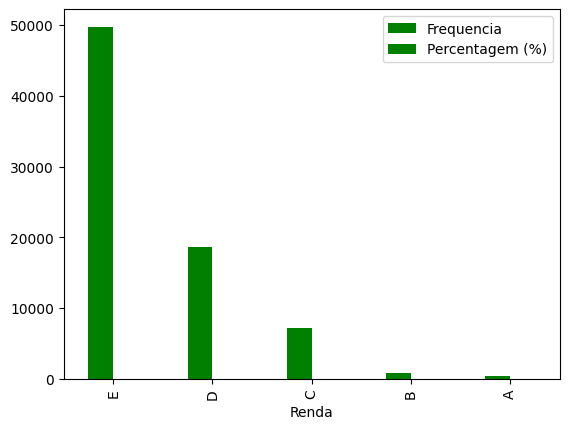

In [ ]:
grafico_de_barras = tabela_frequencia.plot.bar(color = 'green')
grafico_de_barras

> ### Conclusões

Foi observado que mais de 64% da população recebe menos que um salário mínimo, enquanto menos de 1% da população recebe mais que 25 salários mínimo mostrando assim a enorme desigualdade social presente no Brasil.

### Crie um histograma para as variáveis QUANTITATIVAS de nosso dataset
#### <font color='blue'>Descreva os pontos mais relevantes que você observa nos gráficos (assimetrias e seus tipos, possíveis causas para determinados comportamentos etc.)</font>

Text(0, 0.5, 'Frequência')

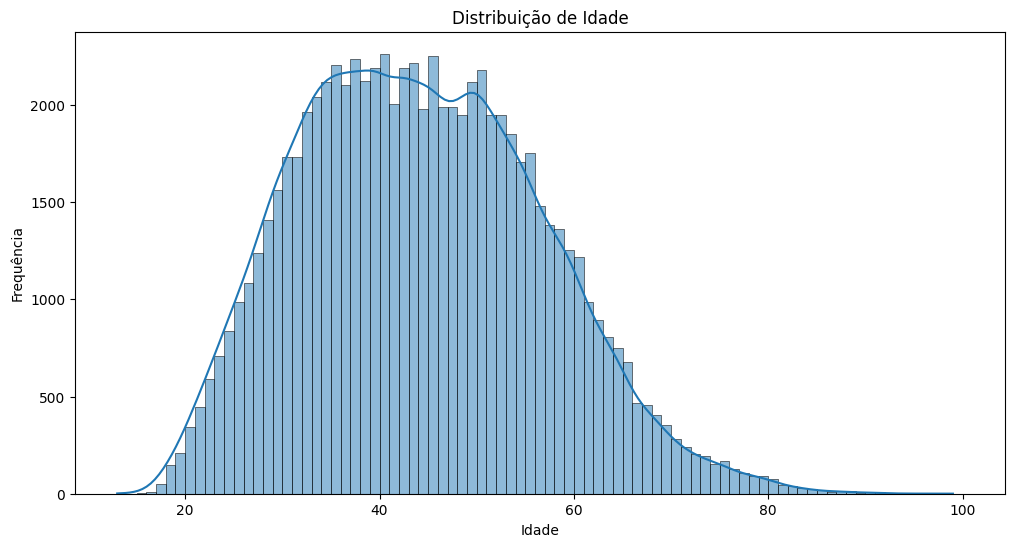

In [ ]:
import numpy as np

ax = seaborn.histplot(dados.Idade, kde = True, bins = np.arange(dados.Idade.min(), dados.Idade.max() + 2, 1))
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de Idade')
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')

Text(0, 0.5, 'Frequência')

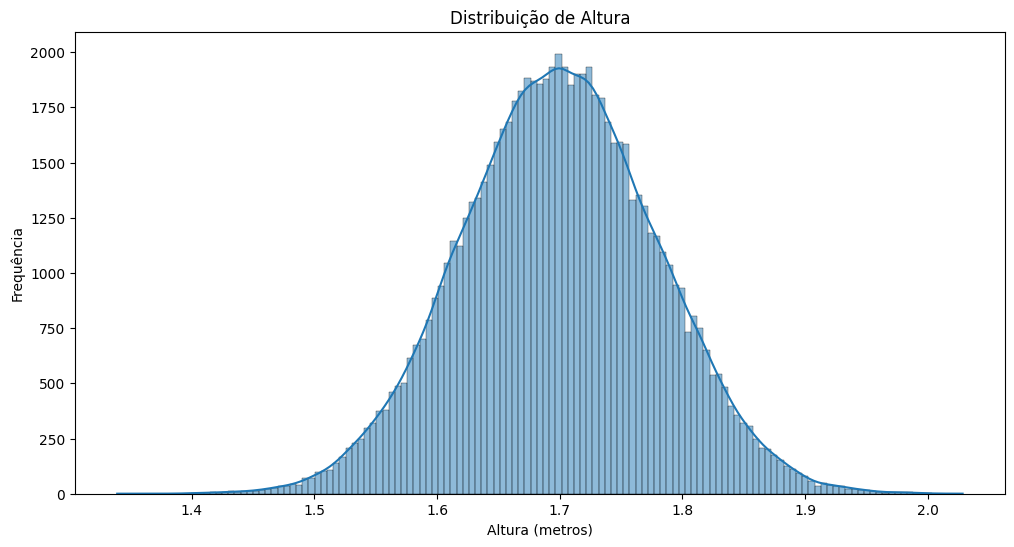

In [ ]:
ax = seaborn.histplot(dados.Altura, kde = True)
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de Altura')
ax.set_xlabel('Altura (metros)')
ax.set_ylabel('Frequência')

Text(0, 0.5, 'Frequência')

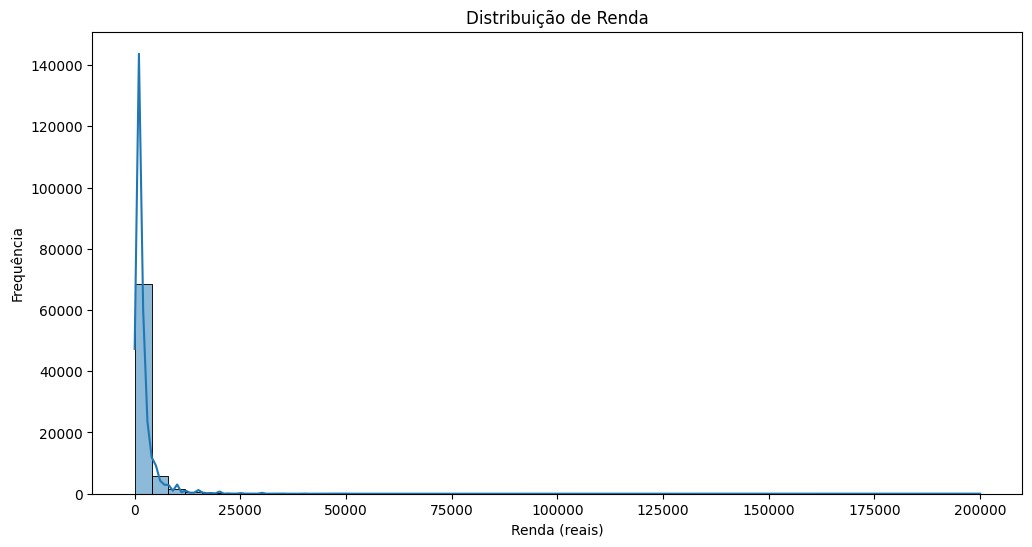

In [ ]:
ax = seaborn.histplot(dados.Renda, kde = True, bins = 50)
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de Renda')
ax.set_xlabel('Renda (reais)')
ax.set_ylabel('Frequência')

> ### Conclusões

Nos histogramas gerados para as variáveis quantitativas, observamos o seguinte:

*   **Idade:** A distribuição de idade se mostra relativamente simétrica, com uma concentração maior de indivíduos nas idades adultas de trabalho. Não há assimetrias extremas, indicando uma distribuição de idade esperada para a população em idade ativa considerada na pesquisa.

*   **Altura:** A distribuição da altura apresenta uma forma aproximadamente normal (simétrica, em formato de sino), concentrando a maioria dos indivíduos em torno de uma altura média. Isso é esperado para características biológicas em grandes populações, onde a maioria dos valores se agrupa perto da média e se dispersa uniformemente para ambos os lados.

*   **Renda:** A distribuição da renda é fortemente assimétrica à direita (positivamente assimétrica). Isso significa que a maior parte da população possui rendimentos mais baixos, enquanto uma pequena parcela detém rendimentos muito altos. Essa assimetria é uma característica comum em dados de renda e reflete a desigualdade socioeconômica, onde a concentração de riqueza está nas mãos de poucos indivíduos, puxando a cauda da distribuição para a direita.

### Para a variável RENDA, construa um histograma somente com as informações das pessoas com rendimento até R$ 20.000,00

Text(0, 0.5, 'Frequencia')

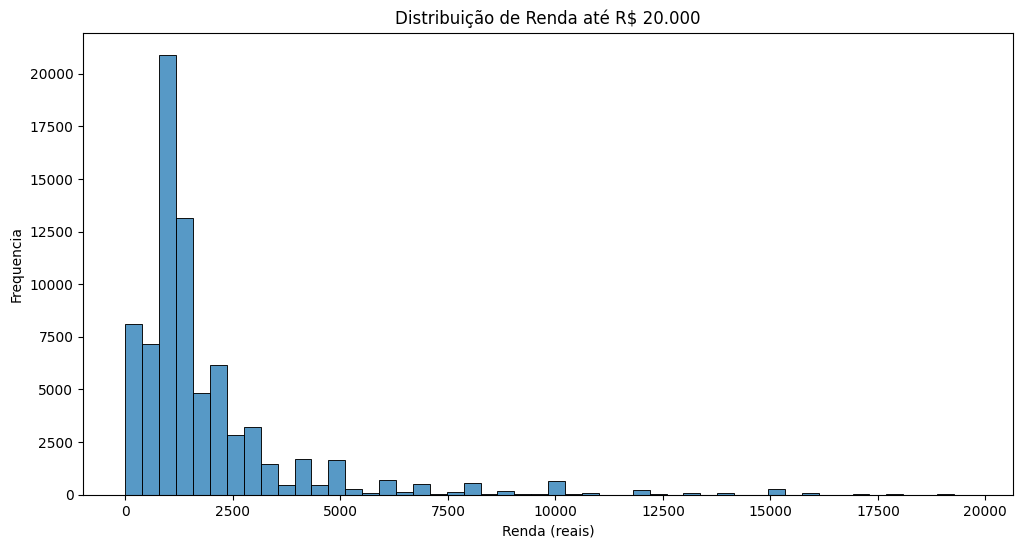

In [ ]:
ax = seaborn.histplot(dados.query('Renda < 20000').Renda, kde = False, bins = 50)
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de Renda até R$ 20.000')
ax.set_xlabel('Renda (reais)')
ax.set_ylabel('Frequencia')

### Construa uma tabela de frequências e uma com os percentuais do cruzando das variáveis SEXO e COR
#### <font color='blue'>Avalie o resultado da tabela e escreva suas principais conclusões</font>
#### <font color='red'>Utilize os dicionários abaixo para renomear as linha e colunas das tabelas de frequências e dos gráficos em nosso projeto</font>

In [ ]:
sexo = {
    0: 'Masculino',
    1: 'Feminino'
}
cor = {
    0: 'Indígena',
    2: 'Branca',
    4: 'Preta',
    6: 'Amarela',
    8: 'Parda',
    9: 'Sem declaração'
}
anos_de_estudo = {
    1: 'Sem instrução e menos de 1 ano',
    2: '1 ano',
    3: '2 anos',
    4: '3 anos',
    5: '4 anos',
    6: '5 anos',
    7: '6 anos',
    8: '7 anos',
    9: '8 anos',
    10: '9 anos',
    11: '10 anos',
    12: '11 anos',
    13: '12 anos',
    14: '13 anos',
    15: '14 anos',
    16: '15 anos ou mais',
    17: 'Não determinados'
}
uf = {
    11: 'Rondônia',
    12: 'Acre',
    13: 'Amazonas',
    14: 'Roraima',
    15: 'Pará',
    16: 'Amapá',
    17: 'Tocantins',
    21: 'Maranhão',
    22: 'Piauí',
    23: 'Ceará',
    24: 'Rio Grande do Norte',
    25: 'Paraíba',
    26: 'Pernambuco',
    27: 'Alagoas',
    28: 'Sergipe',
    29: 'Bahia',
    31: 'Minas Gerais',
    32: 'Espírito Santo',
    33: 'Rio de Janeiro',
    35: 'São Paulo',
    41: 'Paraná',
    42: 'Santa Catarina',
    43: 'Rio Grande do Sul',
    50: 'Mato Grosso do Sul',
    51: 'Mato Grosso',
    52: 'Goiás',
    53: 'Distrito Federal'
}

In [ ]:
frequencia = pandas.crosstab(dados.Sexo, dados.Cor)
frequencia.rename(index = sexo, inplace = True)
frequencia.rename(columns = cor, inplace = True)
frequencia

Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,256,22194,5502,235,25063
Feminino,101,9621,2889,117,10862


In [ ]:
percentual = pandas.crosstab(dados.Sexo, dados.Cor, normalize = True) * 100
percentual.rename(index = sexo, inplace = True)
percentual.rename(columns = cor, inplace = True)
percentual

Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,0.333160,28.883394,7.160333,0.305830,32.617126
Feminino,0.131442,12.520822,3.759761,0.152264,14.135867


> ### Conclusões

Escreva suas conclusões aqui...

## Realize, para a variável RENDA, uma análise descritiva com as ferramentas que aprendemos em nosso treinamento

### Obtenha a média aritimética

In [ ]:
df_media = dados.Renda.mean()
df_media

np.float64(2000.3831988547631)

### Obtenha a mediana

In [ ]:
dados.Renda.median()

1200.0

### Obtenha a moda

In [ ]:
dados.Renda.mode()

,Renda
0,788


### Obtenha o desvio médio absoluto

In [ ]:
desvio_Renda_mad = dados.Renda.sub(dados.Renda.mean()).abs().mean()
desvio_Renda_mad

np.float64(1526.4951371638058)

### Obtenha a variância

In [ ]:
variancia = dados.Renda.var()
variancia

11044906.00622118

### Obtenha o desvio-padrão

In [ ]:
desvio_padrao = dados.Renda.std()
desvio_padrao

3323.3877303470294

### Obtenha a média, mediana e valor máximo da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mean', 'median', 'max'}</i></font>

In [ ]:
tabela_estatisticas_renda = pandas.crosstab(dados.Sexo, dados.Cor,
                                          values=dados.Renda,
                                          aggfunc={'mean', 'median', 'max'})
tabela_estatisticas_renda.rename(index = sexo, inplace = True)
tabela_estatisticas_renda.rename(columns = cor, inplace = True)
tabela_estatisticas_renda

max                                        mean               \
Cor       Indígena  Branca  Preta Amarela   Parda     Indígena       Branca   
Sexo                                                                          
Masculino    10000  200000  50000   50000  100000  1081.710938  2925.744435   
Feminino    120000  100000  23000   20000   30000  2464.386139  2109.866750   

                                                   median                  \
Cor              Preta      Amarela        Parda Indígena  Branca   Preta   
Sexo                                                                        
Masculino  1603.861687  4758.251064  1659.577425    797.5  1700.0  1200.0   
Feminino   1134.596400  3027.341880  1176.758516    788.0  1200.0   800.0   

                           
Cor       Amarela   Parda  
Sexo                       
Masculino  2800.0  1200.0  
Feminino   1500.0   800.0

> ### Conclusões

Escreva suas conclusões aqui...

### Obtenha as medidas de dispersão da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mad', 'var', 'std'}</i></font>

In [ ]:
tabela_estatisticas_renda = pandas.crosstab(dados.Sexo, dados.Cor,
                                          values=dados.Renda,
                                          aggfunc={'var', 'std', lambda x: numpy.mean(numpy.abs(x - numpy.mean(x)))})
tabela_estatisticas_renda.rename(index = sexo, inplace = True)
tabela_estatisticas_renda.rename(columns = cor, inplace = True)
tabela_estatisticas_renda

<lambda_0>                                                     \
Cor           Indígena       Branca       Preta      Amarela        Parda   
Sexo                                                                        
Masculino   798.910889  2261.012346  975.602482  3709.597211  1125.827704   
Feminino   3007.892952  1670.967106  705.453357  2549.146322   811.580946   

                    std                                                     \
Cor            Indígena       Branca        Preta     Amarela        Parda   
Sexo                                                                         
Masculino   1204.093490  4750.791872  1936.309271  5740.82482  2312.087184   
Feminino   11957.498292  3251.013154  1349.799809  3731.17366  1596.233048   

                    var                                            \
Cor            Indígena        Branca         Preta       Amarela   
Sexo                                                                
Masculino  1.449841e+06  2.257002e+07  3.749294e+06  3.295707e+07   
Feminino   1.429818e+08  1.056909e+07  1.821960e+06  1.392166e+07   

                         
Cor               Parda  
Sexo                     
Masculino  5.345747e+06  
Feminino   2.547960e+06

> ### Conclusões

Escreva suas conclusões aqui...

### Construa um box plot da variável RENDA segundo SEXO e COR
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

<Axes: title={'center': 'Distribuição de Renda por Sexo e Cor (até R$ 10.000)'}, xlabel='Renda (R$)', ylabel='Sexo'>

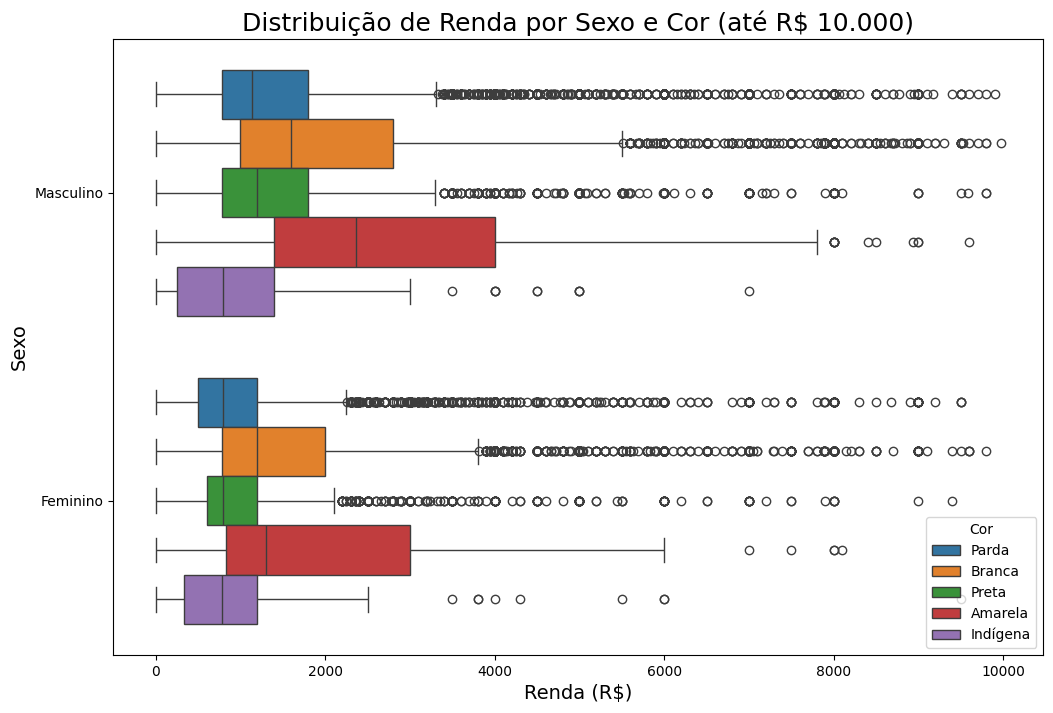

In [ ]:
# Create a copy of the filtered data to avoid modifying the original DataFrame
df_plot = dados.query('Renda < 10000').copy()

# Map numeric codes to descriptive names for plotting
df_plot['Sexo'] = df_plot['Sexo'].map(sexo)
df_plot['Cor'] = df_plot['Cor'].map(cor)

ax = seaborn.boxplot(x='Renda', y='Sexo', hue='Cor', data=df_plot, orient='h')
ax.figure.set_size_inches(12, 8) # Adjusted height for better readability with hue
ax.set_title('Distribuição de Renda por Sexo e Cor (até R$ 10.000)', fontsize=18)
ax.set_xlabel('Renda (R$)', fontsize=14)
ax.set_ylabel('Sexo', fontsize=14)
ax

> ### Conclusões

No box plot da variável RENDA, segmentado por Sexo e Cor (para rendas abaixo de R$ 10.000), podemos observar alguns comportamentos diferenciados:

*   **Desigualdade de Renda por Sexo:** Em quase todas as categorias de cor, a mediana da renda para homens é visivelmente maior do que para mulheres. Além disso, a dispersão (tamanho da caixa do box plot) e os valores máximos (fim dos 'bigodes' e pontos de outliers) para homens geralmente se estendem a faixas de renda mais altas do que para mulheres.

*   **Desigualdade de Renda por Cor:**
    *   **Brancos e Amarelos:** Geralmente apresentam as medianas de renda mais elevadas, caixas mais longas (maior dispersão) e a presença de outliers com rendas significativamente maiores, tanto para homens quanto para mulheres.
    *   **Pardos e Pretos:** Tendem a ter medianas de renda mais baixas e uma menor dispersão, indicando que a maioria das pessoas nesses grupos se concentra em faixas de renda mais modestas. Os outliers, quando presentes, também são menos extremos em comparação com os grupos Brancos e Amarelos.
    *   **Indígenas:** Apresentam as menores medianas de renda e, em alguns casos, as menores dispersões, refletindo uma concentração em rendimentos mais baixos.

*   **Outliers:** A presença de vários pontos fora dos 'bigodes' em categorias como 'Masculino - Branca' e 'Masculino - Amarela' indica que, mesmo dentro da faixa de renda abaixo de R$ 10.000, há indivíduos com rendimentos consideravelmente mais altos que a maioria de seu grupo, contribuindo para a assimetria da distribuição de renda já observada nos histogramas.

Em resumo, o box plot reforça as conclusões anteriores sobre a desigualdade de renda no Brasil, mostrando que ela é acentuada tanto por questões de gênero quanto de raça/cor, com homens e indivíduos de cor branca/amarela geralmente ocupando posições de maior renda e com maior variabilidade.

# <font color="red">DESAFIO<font>
### Qual percentual de pessoas de nosso <i>dataset</i> ganham um salário mínimo (R$ 788,00) ou menos?
#### <font color='red'>Utilize a função <i>percentileofscore()</i> do <i>scipy</i> para realizar estas análises.</font>
#### Mais informações: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html


In [ ]:
from scipy import stats

percentual_salario_minimo = stats.percentileofscore(dados.Renda, 788)
percentual_salario_minimo

np.float64(24.390942217595)

### Qual o valor máximo ganho por 99% das pessoas de nosso <i>dataset</i>?
#### <font color='red'>Utilize o método <i>quantile()</i> do <i>pandas</i> para realizar estas análises.</font>

In [ ]:
percentual_maximo = dados.Renda.quantile(0.99)
percentual_maximo

np.float64(15000.0)

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = ['mean', 'median', 'max', 'std']</i></font>

In [ ]:
tabela_estatisticas_renda = pandas.crosstab(dados.Sexo, dados['Anos de Estudo'],
                                          values=dados.Renda,
                                          aggfunc={'mean', 'median', 'max', 'std'})
tabela_estatisticas_renda.rename(index = sexo, inplace = True)
tabela_estatisticas_renda.rename(columns = anos_de_estudo, inplace = True)
tabela_estatisticas_renda

max                              \
Anos de Estudo Sem instrução e menos de 1 ano  1 ano 2 anos 3 anos 4 anos   
Sexo                                                                        
Masculino                               30000  30000  40000  80000  50000   
Feminino                                10000   2000   4000   3500  10000   

                                                   ...          std  \
Anos de Estudo 5 anos 6 anos 7 anos 8 anos 9 anos  ...       7 anos   
Sexo                                               ...                
Masculino       35000  25000  40000  30000  60000  ...  1419.708673   
Feminino         8000   6000   9000  18000  20000  ...   602.038029   

                                                                    \
Anos de Estudo       8 anos       9 anos      10 anos      11 anos   
Sexo                                                                 
Masculino       1515.583715  2137.664774  2078.609734  2676.538942   
Feminino         896.781213   973.221652   620.611907  1819.040417   

                                                                       \
Anos de Estudo      12 anos      13 anos      14 anos 15 anos ou mais   
Sexo                                                                    
Masculino       2268.081538  2797.116800  3987.214974     7447.613594   
Feminino        4851.833513  2053.789771  2064.083336     4212.770709   

                                 
Anos de Estudo Não determinados  
Sexo                             
Masculino            979.648745  
Feminino             459.985964  

[2 rows x 68 columns]

### Construa um box plot da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Utilize a variável IDADE para identificar se a desigualdade se verifica para pessoas de mesma idade. Exemplo: <i>data=dados.query('Renda < 10000 and Idade == 40')</i> ou <i>data=dados.query('Renda < 10000 and Idade == 50')</i></font>
#### <font color='red'>3º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

<Axes: title={'center': 'Distribuição de Renda por Sexo e Cor (até R$ 10.000)'}, xlabel='Renda (R$)', ylabel='Sexo'>

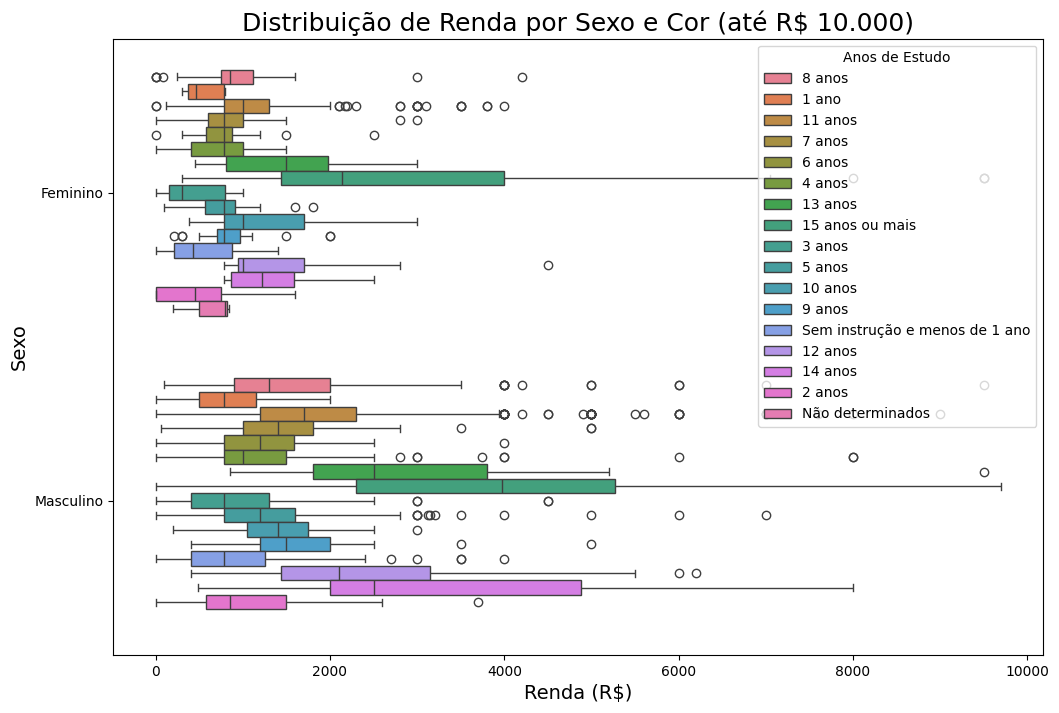

In [ ]:
# Create a copy of the filtered data to avoid modifying the original DataFrame
df_plot = dados.query('Renda < 10000 and Idade == 40').copy()

# Map numeric codes to descriptive names for plotting
df_plot['Sexo'] = df_plot['Sexo'].map(sexo)
df_plot['Anos de Estudo'] = df_plot['Anos de Estudo'].map(anos_de_estudo)

ax = seaborn.boxplot(x='Renda', y='Sexo', hue='Anos de Estudo', data=df_plot, orient='h')
ax.figure.set_size_inches(12, 8) # Adjusted height for better readability with hue
ax.set_title('Distribuição de Renda por Sexo e Cor (até R$ 10.000)', fontsize=18)
ax.set_xlabel('Renda (R$)', fontsize=14)
ax.set_ylabel('Sexo', fontsize=14)
ax

> ### Conclusões

Escreva suas conclusões aqui...

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>Utilize o método <i>groupby()</i> do <i>pandas</i> juntamente com o método <i>agg()</i> para contruir a tabulação. O método <i>agg()</i> pode receber um dicionário especificando qual coluna do DataFrame deve ser utilizada e qual lista de funções estatísticas queremos obter, por exemplo: <i>dados.groupby(['UF']).agg({'Renda': ['mean', 'median', 'max', 'std']})</i></font>

In [ ]:
tabela_estatisticas_uf = dados.groupby(['UF']).agg({'Renda': ['mean', 'median', 'max', 'std']})
tabela_estatisticas_uf.rename(index = uf, inplace = True)
tabela_estatisticas_uf

Renda                             
                            mean  median     max          std
UF                                                           
Rondônia             1789.761223  1200.0   50000  2406.161161
Acre                 1506.091782   900.0   30000  2276.233415
Amazonas             1445.130100   900.0   22000  1757.935591
Roraima              1783.588889  1000.0   20000  2079.659238
Pará                 1399.076871   850.0   50000  2053.779555
Amapá                1861.353516  1200.0   15580  2020.688632
Tocantins            1771.094946  1000.0   60000  2934.590741
Maranhão             1019.432009   700.0   30000  1887.816905
Piauí                1074.550784   750.0   40000  2373.355726
Ceará                1255.403692   789.0   25000  1821.963536
Rio Grande do Norte  1344.721480   800.0   15500  1651.805500
Paraíba              1293.370487   788.0   30000  1950.272431
Pernambuco           1527.079319   900.0   50000  2389.622497
Alagoas              1144.552602   788.0   11000  1237.856197
Sergipe              1109.111111   788.0   16000  1478.997878
Bahia                1429.645094   800.0  200000  3507.917248
Minas Gerais         2056.432084  1200.0  100000  3584.721547
Espírito Santo       2026.383852  1274.0  100000  3513.846868
Rio de Janeiro       2496.403168  1400.0  200000  5214.583518
São Paulo            2638.104986  1600.0   80000  3503.777366
Paraná               2493.870753  1500.0  200000  4302.937995
Santa Catarina       2470.854945  1800.0   80000  3137.651112
Rio Grande do Sul    2315.158336  1500.0   35000  2913.335783
Mato Grosso do Sul   2262.604167  1500.0   42000  3031.419122
Mato Grosso          2130.652778  1500.0   35000  2542.630178
Goiás                1994.580794  1500.0   30000  2221.933065
Distrito Federal     4241.954722  2000.0  100000  5550.463338

> ### Conclusões

Escreva suas conclusões aqui...

### Construa um box plot da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>

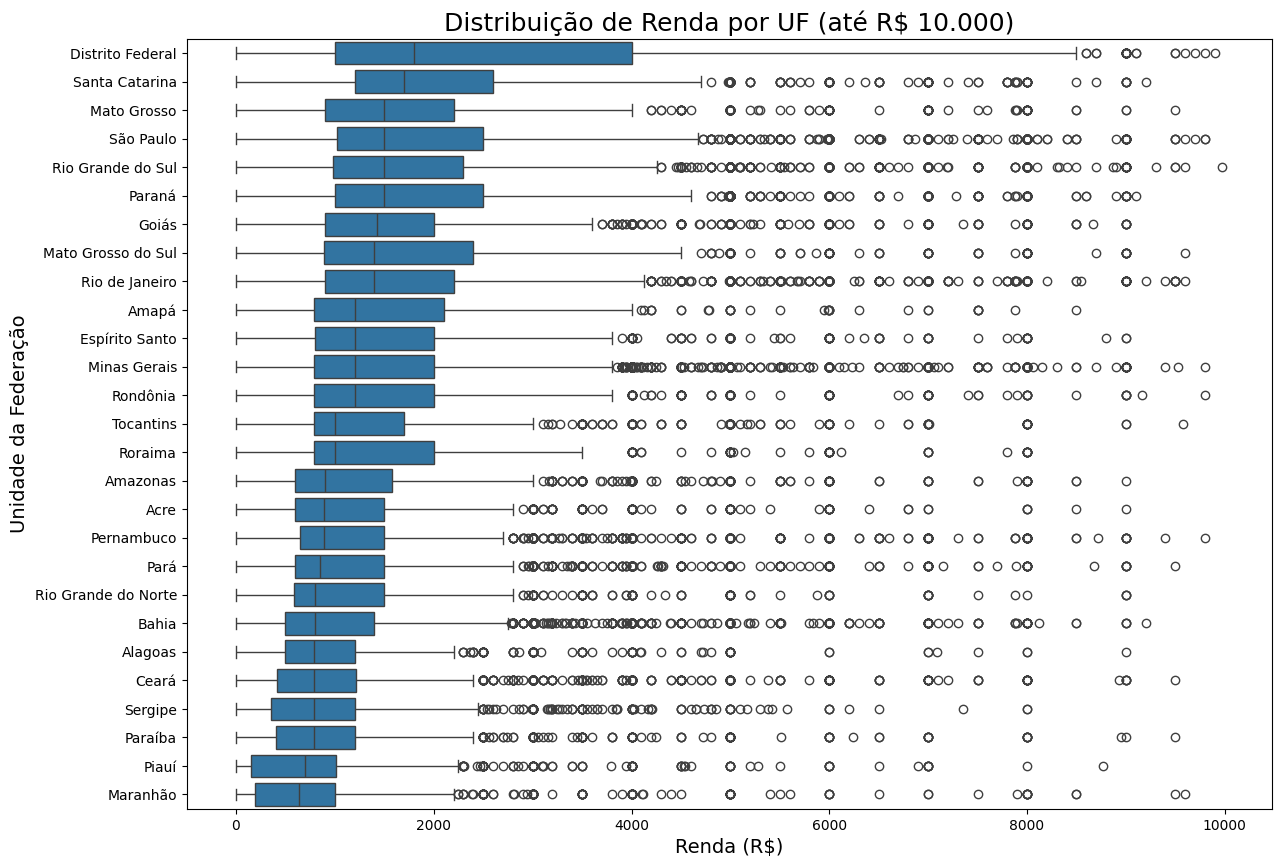

In [ ]:
import matplotlib.pyplot as plt

# Create a copy of the filtered data to avoid modifying the original DataFrame
df_plot_uf = dados.query('Renda < 10000').copy()

# Map numeric codes to descriptive names for plotting
df_plot_uf['UF'] = df_plot_uf['UF'].map(uf)

# Order the UF by median income for better visualization
median_income_by_uf = df_plot_uf.groupby('UF')['Renda'].median().sort_values(ascending=False).index

ax = seaborn.boxplot(x='Renda', y='UF', data=df_plot_uf, orient='h', order=median_income_by_uf)
ax.figure.set_size_inches(14, 10)
ax.set_title('Distribuição de Renda por UF (até R$ 10.000)', fontsize=18)
ax.set_xlabel('Renda (R$)', fontsize=14)
ax.set_ylabel('Unidade da Federação', fontsize=14)
plt.show()

> ### Conclusões

Escreva suas conclusões aqui...

> ### Conclusões

Escreva suas conclusões aqui...